# Class Imbalance ⚖️

> Class imbalance occurs when target classes have significantly different numbers of observations.

Example:

`Class 0 → 95%`

`Class 1 → 5%`

## 1. Detection

### Count

```python
df["Target"].value_counts()
````

### Percentage

```python
df["Target"].value_counts(
    normalize=True
) * 100
```

Check whether one class is heavily underrepresented.

## 2. Visualization

### Bar Chart

```python
df["Target"].value_counts().plot(
    kind="bar"
)
```

### Pie Chart

```python
df["Target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
```

Bar charts are generally easier for class comparison.

## 3. Business Implications

Class imbalance can make **accuracy misleading**.

Example:

`99% Normal + 1% Fraud`

A model predicting every case as Normal gets `99% accuracy` but detects `0%` of fraud.

For imbalanced classification, consider:

* Precision
* Recall
* F1 Score
* ROC-AUC
* PR-AUC

### Precision

Of predicted positives, how many are actually positive?

`Precision = TP / (TP + FP)`

### Recall

Of actual positives, how many were detected?

`Recall = TP / (TP + FN)`

### F1 Score

Harmonic mean of precision and recall.

`F1 = 2 × Precision × Recall / (Precision + Recall)`

## Important

**Do not automatically use accuracy for imbalanced data.**

Choose evaluation metrics based on the **business cost of false positives and false negatives**.

## Key Workflow

**Detect → Calculate proportions → Visualize → Understand business cost → Choose appropriate metrics**

```
```


In [49]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10000

df = pd.DataFrame({
    "Transaction_ID": range(1, n + 1),
    "Amount": np.random.randint(300,2100, n),
    "Age": np.random.randint(18, 70, n),
    "Fraud": np.random.choice(
        [0, 1],
        size=n,
        p=[0.98, 0.02]
    )
})

In [50]:
df['Fraud'].value_counts()

Fraud
0    9770
1     230
Name: count, dtype: int64

<Axes: xlabel='Fraud'>

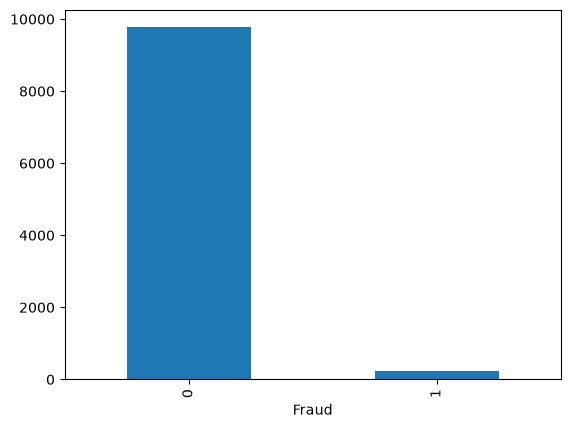

In [51]:
df['Fraud'].value_counts().plot(kind = 'bar')

In [52]:
import pandas as pd

bins = [18,25,40,55,70]
labels=['18-25','25-40','40-55','55-70']

df['Age_Group'] = pd.cut(df['Age'], bins = bins, labels = labels)

In [53]:
fraud_contacts = df[df['Fraud'] == 1]['Age_Group'].value_counts().sort_index()

In [54]:
fraud_contacts

Age_Group
18-25    40
25-40    60
40-55    72
55-70    55
Name: count, dtype: int64

<Axes: >

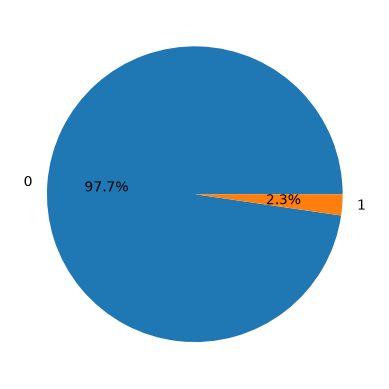

In [55]:
df['Fraud'].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

In [56]:
df

,Transaction_ID,Amount,Age,Fraud,Age_Group
0,1,1426,59,0,55-70
1,2,1759,67,0,55-70
2,3,1160,40,0,25-40
3,4,1594,24,0,18-25
4,5,1430,56,0,55-70
...,...,...,...,...,...
9995,9996,1398,27,0,25-40
9996,9997,1277,56,0,55-70
9997,9998,1805,47,1,40-55
9998,9999,1426,43,0,40-55


In [57]:
df['Amount'].describe()

count    10000.000000
mean      1204.155700
std        515.328335
min        300.000000
25%        762.750000
50%       1210.000000
75%       1647.000000
max       2099.000000
Name: Amount, dtype: float64

In [61]:
bins = [300,600,900,1200,1500,1800,2100]
labels = ['300-600','600-900','900-1200','1200-1500','1500-1800','1800-2100']

df['Amount_Range'] = pd.cut(df['Amount'],bins = bins, labels = labels)

In [63]:
fraud_Amounts = df[df['Fraud'] == 1]['Amount_Range'].value_counts().sort_index()

In [64]:
fraud_Amounts

Amount_Range
300-600      38
600-900      38
900-1200     37
1200-1500    42
1500-1800    31
1800-2100    43
Name: count, dtype: int64